# Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
plt.rcParams['figure.figsize'] = [8, 5]

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import tree
from sklearn.linear_model import LinearRegression
from scipy.stats import norm

from code.chi_sq_distr_func import compute_p_value, chi_sq_cdf_sim
import numpy as np
from scipy.integrate import quad
from scipy.integrate import dblquad
from scipy.special import gamma
import time
from tqdm import tqdm

ModuleNotFoundError: No module named 'code.chi_sq_distr_func'; 'code' is not a package

## Table for in sample vs outsample pvals

In [104]:
def _get_metrics(rt):
    """
    Retrieves P-values for all split nodes of the tree 
    """

    n_nodes = rt.tree_.node_count
    children_left = rt.tree_.children_left
    children_right = rt.tree_.children_right
    impurities = rt.tree_.impurity
    sample_size = rt.tree_.n_node_samples
    
    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaves = np.zeros(shape=n_nodes, dtype=bool)

    # Populate values
    mseps = -1*np.ones(shape=n_nodes, dtype=np.float64) # Ratio drop of making split per node
    ratios = -1*np.ones(shape=n_nodes, dtype=np.float64) # Ratio drop of making split per node
    pvals = -1*np.ones(shape=n_nodes, dtype=np.float64) # P-values based on rations per node
    reduction = np.nan*np.ones(shape=n_nodes, dtype=np.float64) # the absolute reduction of total mse if split is made in node
    # The reduction enables us to decide the split sequence

    stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
    while len(stack) > 0:
        # `pop` ensures each node is only visited once
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
        
        # If the left and right child of a node is not the same we have a split
        # node
        is_split_node = children_left[node_id] != children_right[node_id]
        
        # If a split node, append left and right children and depth to `stack`
        # so we can loop through them
        if is_split_node:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
            
            mse = impurities[node_id]
            mse_left = impurities[children_left[node_id]]
            mse_right = impurities[children_right[node_id]]
        
            n = sample_size[node_id]
            n_left = sample_size[children_left[node_id]]
            n_right = sample_size[children_right[node_id]]
            
            # Make the Variance unbiased
            mse *= n/(n-1)
            mse_left *= n_left/(n_left-1)
            mse_right *= n_right/(n_right-1) 

            # Mathias suggestion
            #mse *= (1 + 1/n)
            mse_left *= (1 + 1/n_left)
            mse_right *= (1 + 1/n_right)
            
            msep1 = (n_left + 1)*mse_left + (n_right + 1)*mse_right
            mseps[node_id] = msep1
            msep0 = (n + 1)*mse
            r = msep1/msep0
            ratios[node_id] = r

            # Add new function
            #p = compute_p_value(n_left, n_right, r)
            
            p = chi_sq_cdf_sim(n_left, n_right, r, int(1e5))
            pvals[node_id] = p            
        else:
            is_leaves[node_id] = True

    #splitting_sequence = np.argsort(reduction)[:-np.sum(np.isnan(reduction))] # order and remove the leaf indices, LEAF=NAN! FALSE!
    return pvals, is_leaves, ratios, mseps

def get_pvals_test(rt, X, y, correction = False):
    n_nodes = rt.tree_.node_count
    children_left = rt.tree_.children_left
    children_right = rt.tree_.children_right
    sample_size = rt.tree_.n_node_samples
    impurities = rt.tree_.impurity
    
    data_path = rt.decision_path(X).toarray()
    
    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    pvals_test = -np.ones(shape=n_nodes, dtype=np.float64)
    ratio_test = -np.ones(shape=n_nodes, dtype=np.float64)
    stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
    while len(stack) > 0:
        # `pop` ensures each node is only visited once
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
    
        # If the left and right child of a node is not the same we have a split
        # node
        left_child_id = children_left[node_id]
        right_child_id = children_right[node_id]
        is_split_node = left_child_id != right_child_id
        # If a split node, append left and right children and depth to `stack`
        # so we can loop through them
        if is_split_node:
            stack.append((left_child_id, depth + 1))
            stack.append((right_child_id, depth + 1))
           
            # Calculate ratio
    
            # Index for test data
            left_ind = np.nonzero(data_path[:, left_child_id])[0]
            right_ind = np.nonzero(data_path[:, right_child_id])[0]

            # Calculate ratio for each node
            n_left = len(left_ind)
            n_right = len(right_ind)
            n = n_left + n_right

            if n_left<2 or n_right<2:
                pvals[node_id] = 100
                continue

            y_left = y[left_ind]
            y_right = y[right_ind]

            ### OUR METHOD
            """
            msep_left =  np.var(y_left, ddof=1)
            msep_left *= (1 + 2/n_left)*(n_left/n)
            
            msep_right = np.var(y_right, ddof=1)
            msep_right *= (1 + 2/n_right)*(n_right/n)
            
            msep = np.var(np.concatenate([y_left, y_right]), ddof=1)
            msep *= (1 + 2/n)
            
            
            if correction:
                # Mathias Correction
                msep_left *= np.sqrt((1+ 8/n_left))
                msep_right *= np.sqrt((1+8/n_right))
                #msep *= (1-2/n)
                
            ratio = msep_left + msep_right
            ratio /= msep
                
            
            #ratio = (n_left+1)*mse_left + (n_right+1)*mse_right
            #ratio /= (n+1)*mse
            
            ratio_test[node_id] = ratio
            
            #p = compute_p_value(n_left, n_right, ratio)
            p = chi_sq_cdf_sim(n_left, n_right, ratio, int(1e5))
            pvals_test[node_id] = p
            """
            ### HAWKINS STATISTIC
            sse_left =  n_left*np.var(y_left,ddof=0)
            sse_right = n_right*np.var(y_right,ddof=0)
            sse = n*np.var(np.concatenate([y_left, y_right]), ddof=0)
            
            T = (sse - sse_right - sse_left)/(sse/n)
            p = F_Tn_sq(n,T)
            pvals_test[node_id] = 1-p
    return pvals_test, ratio_test

def F_Tn_sq(n, u):
    K = np.sqrt(u) - ((2*(np.log(np.log(n))))**(-1/2))*(np.log(np.log(np.log(n))) + np.log(2))
    p = norm.cdf(K)**(2*np.log(n/2))
    return p

In [205]:
# Neufeld Data generation
N = int(1e4) # number of samples
p = 10 # number of covariates
sig = 5
b = 1
a = -5

X = np.random.normal(0,1, (N,p))
eps = np.random.normal(0,sig, N)

mu = b*(X[:, 0] <= 0)*(1 + a*(X[:,1] >0 ) + ((X[:,1]*X[:,2]) > 0) )
y = mu + eps

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [206]:
max_depth = 5
min_samples_leaf = 2

rt = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf) 
path = rt.cost_complexity_pruning_path(X_train, y_train)
ccps, impurities = path.ccp_alphas, path.impurities
#rt = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, ccp_alpha=ccps[0]) 
#rt.fit(X_train, y_train)
# The CCP_Alphas are the minimum "local" reduction need for the split to be accepted.
# The impurities are the sample weighted sum of mses in leaves.
#_ = tree.plot_tree(rt, node_ids=True)

In [207]:
data = []

for c in ccps[:-1]:
    tr = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, ccp_alpha=c)
    tr.fit(X_train, y_train)

    pred = tr.predict(X_train)
    msep = pred - y_train
    msep = msep**2
    msep = np.mean(msep)
    
    pvals, ratios = get_pvals_test(tr, X_train, y_train)
    #ps = np.sum([i for i in pvals if i>=0])
    ps = np.min([i for i in pvals if i>=0])
    ratio = np.max(ratios)
    
    # Test error
    pred = tr.predict(X_test)
    msep_test = pred - y_test
    msep_test = msep_test**2
    msep_test = np.mean(msep_test)

    n_regions = tr.tree_.n_leaves # number of leaves

    pvals_test, ratios_test = get_pvals_test(tr, X_test, y_test)
    #pst = np.sum([i for i in pvals_test if i>=0])
    pst = np.min([i for i in pvals_test if i>=0])
    ratio_test = np.max(ratios_test)
    
    data.append((c, ps, pst, msep, msep_test, n_regions, ratio, ratio_test))

table = pd.DataFrame(data, columns=["ccps", "p_summed", "p_test_summed", "msep_train", "msep_test", "terminal_regions", "max_ratio", "max_ratio_test"])#.iloc[::-1]
table

In [208]:
# There were some issues in the pvalue calculations when using the function Nils Created!
table = pd.DataFrame(data, columns=["ccps", "p_summed", "p_test_summed", "msep_train", "msep_test", "terminal_regions", "max_ratio", "max_ratio_test"])#.iloc[::-1]
table

,ccps,p_summed,p_test_summed,msep_train,msep_test,terminal_regions,max_ratio,max_ratio_test
0,0.000000,0.565115,2.601686e-07,24.438100,26.625954,27,-1.0,-1.0
1,0.001408,0.565115,2.601686e-07,24.439508,26.720500,26,-1.0,-1.0
2,0.019273,0.565115,2.601686e-07,24.458781,26.657823,25,-1.0,-1.0
3,0.020550,0.565115,2.601686e-07,24.458781,26.657823,25,-1.0,-1.0
4,0.024524,0.716709,4.551503e-07,24.524405,26.633700,22,-1.0,-1.0
5,0.025903,0.716709,4.551503e-07,24.550308,26.607870,21,-1.0,-1.0
6,0.026874,0.716709,4.551503e-07,24.577181,26.533566,20,-1.0,-1.0
7,0.034852,0.787021,4.551503e-07,24.612033,26.446362,19,-1.0,-1.0
8,0.037290,0.787021,4.551503e-07,24.612033,26.446362,19,-1.0,-1.0
9,0.037761,0.787021,4.551503e-07,24.687084,26.293010,17,-1.0,-1.0


## Splitting Path

In [135]:
# New node_leaf_map
p = np.array(rt.decision_path(X_train).nonzero())

# Maps each train datapoint through a specific node
point_map = {}
for point, node_id in p.T:
    point_map.setdefault(point, []).append(node_id)

# From point map it is easy to get the terminal node of each leaf
leafs = {}
for _, node_seq in point_map.items():
    sorted = np.sort(node_seq)

    leaf = sorted[-1]
    for node_ in sorted[:-1]:
        leafs.setdefault(node_, []).append(leaf)

# Create a mapper between node and leafs
node_leaf_map = {}
for key, value in leafs.items():
    leaf_ind = np.unique(value)
    node_leaf_map[key] = np.zeros(rt.tree_.node_count)
    node_leaf_map[key][leaf_ind] =1

#node_leaf_map gives all the leafs of a specific node

impurities = rt.tree_.impurity
sample_size = rt.tree_.n_node_samples

ccp_prune_path = []
ccp_my = [0.0]
while(node_leaf_map): # As long as map is populated continue
    alpha_eff = np.nan*np.zeros(rt.tree_.node_count)

    # Calculate alpha_eff for on itteration
    for node_, leaves_ in node_leaf_map.items():
        leaf_ind = np.bool_(leaves_)
        R_t = sample_size[node_]*impurities[node_]
        R_T_t = np.sum(impurities[leaf_ind] * sample_size[leaf_ind])
        alpha_eff[node_] = ((R_t - R_T_t)/(np.sum(leaf_ind)-1))/len(y_train)
    

    ccp_my.append(np.nanmin(alpha_eff))
    weakest_link = np.nanargmin(alpha_eff)
    weakest_link_leaves = np.nonzero(node_leaf_map[weakest_link])[0]
    
    ccp_prune_path.append(weakest_link)
    # Remove the weakest link in the tree
    del node_leaf_map[weakest_link]
    #print(node_leaf_map.keys())
    
    # Need to readjust the node_leaf_map to make the new tree now view weakest link as a leaf.
    children_to_drop = []
    for node_, leaves_ in node_leaf_map.items():
        #print(node_, leaves_[weakest_link_leaves])
        if np.sum(leaves_[weakest_link_leaves]) > 0: # Leaves are under this node

            # The children of weakest link that are not leaves also has to be removed from the map.
            if weakest_link <= node_: #check if the weakest link is parent to this node, then drop this node
                children_to_drop.append(node_) # Cannot remove elements of dict when itterating through dict.
            else:
                node_leaf_map[node_][weakest_link_leaves] = 0
                node_leaf_map[node_][weakest_link] = 1

    for d in children_to_drop:
        del node_leaf_map[d]

In [263]:
# Get the parent node of each child, -1 means no parents!
children_left = rt.tree_.children_left
children_right = rt.tree_.children_right

parent_node = -np.ones(shape=n_nodes, dtype=np.int64)
for parent, child in enumerate(children_left):
    if child > 0:
        parent_node[child] = parent
for parent, child in enumerate(children_right):
    if child > 0:
        parent_node[child] = parent

# for all leaves do something, from bottom up we can construct an algorithm gives us the splitting path
# Create a stack that we should go through an itteratively remove a leaf.

stack = [i for i,l in enumerate(is_leaves) if l]
while len(stack) > 0:
    print(stack)

## Ratio In-Sample vs Out-of-sample

In [802]:
def calculate_ratio(rt, X, y, correction = False):
    prow, pcol = rt.decision_path(X).nonzero()
    data_left_ind = prow[pcol == 1]
    data_right_ind = prow[pcol == 2]


    n_left = np.size(data_left_ind)
    n_right = np.size(data_right_ind)
    n = n_left + n_right

    if np.any(np.array([n_left, n_right, n]) < 2):
        return False, False


    """
    msep_left = (y[data_left_ind] - rt.predict(X[data_left_ind,:]))**2
    msep_left = np.sum(msep_left)/(n_left -1 ) # MSE
    msep_left *= (1 + 1/n_left)*(n_left/n) # Uncertainty correction

    msep_right = (y[data_right_ind] - rt.predict(X[data_right_ind,:]))**2
    msep_right = np.sum(msep_right)/(n_right - 1) # MSE
    msep_right *= ( 1+ 1/n_right)*(n_right/n) # Uncertainty correction

    msep = (y - rt.predict(X))**2
    msep = np.sum(msep)/(n - 1)
    msep *= (1 + 1/n)

    """
    # Everything empirical
    msep_left =  np.var(y[data_left_ind], ddof=1)
    msep_left *= (1 + 2/n_left)*(n_left/n)
    
    msep_right = np.var(y[data_right_ind], ddof=1)
    msep_right *= (1 + 2/n_right)*(n_right/n)
    
    msep = np.var(y, ddof=1)
    msep *= (1 + 1/n)
    
    
    if correction:
        # Mathias Correction
        msep_left *= (1+ 4/n_left)
        msep_right *= (1+ 4/n_right)
        #msep *= (1-2/n)
        
    ratio = msep_left + msep_right
    ratio /= msep
    
    return ratio, n_left

def empirical_pval(y,p):
    sorted_y = np.sort(y)
    n = len(y)
    i = int(n*p)

    return sorted_y[i]

In [803]:
N = int(1e4)
std = 5
true_split_point = 0.5

mu = lambda x: 10 #- 5*np.int64(x<=true_split_point)

n_iter = int(1e3)
#r_train = -np.ones(n_iter)
#r_test = -np.ones(n_iter)

r_train = []#-np.ones(n_iter)
r_test = []#-np.ones(n_iter)
n_as = []

for i in tqdm(range(n_iter)):    
    X = np.random.uniform(size=(N,1))
    y = mu(X[:, 0])
    
    # Add randomness
    eps = np.random.normal(0, std, size=N)
    y = y + eps
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

    rt = tree.DecisionTreeRegressor(max_depth=1, min_samples_leaf=2)
    rt.fit(X_train, y_train)

    

    rtr, nltr = calculate_ratio(rt, X_train, y_train, correction=True)
    rt, nlt = calculate_ratio(rt, X_test, y_test)
    
    if rt:
        r_train.append(rtr)
        r_test.append(rt)
        n_as.append(nltr)

100%|████████████████████████████████████████████| 1000/1000 [00:01<00:00, 677.79it/s]


(0.9975642502675299, 0.9982117684071394)

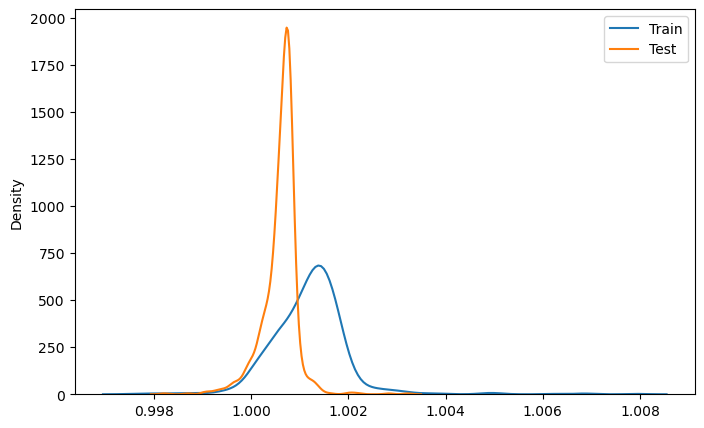

In [804]:
f, ax = plt.subplots(1, 1, figsize=(8,5))
sb.kdeplot(r_train, label="Train")
sb.kdeplot(r_test, label="Test")
#plt.title("No signal, no correction")
ax.legend()

p = 0.0001
empirical_pval(r_train, p), empirical_pval(r_test, p)

## Min Distribution



In [1064]:
mu = lambda x: 10 #- 5*np.int64(x<=true_split_point)

N = int(1e2)
std = 1
X = np.random.uniform(size=(N,1))
y = mu(X[:, 0])
# Add randomness
eps = np.random.normal(0, std, size=N)
y = y + eps

sort_ind = np.argsort(X[:,0])
X = X[sort_ind,:]
y = y[sort_ind]

In [1065]:
tot_mse = []
tot_msep = []
for i in range(2,len(sort_ind)-2):
    n_left = len(y[:i])
    n_right = len(y[i:])
    n = n_left + n_right
    
    mse_left = n_left*np.var(y[:i])
    mse_right = n_right*np.var(y[i:])
    mse = (mse_left + mse_right)/(len(y)*np.var(y)) #- len(y)*np.var(y)
    tot_mse.append(mse)

    mse_left = (n_left/n)*(1 + 1/n_left)*np.var(y[:i], ddof=1)
    mse_right = (n_right/n)*(1 + 1/n_right)*np.var(y[i:], ddof=1)
    mse = (1+1/n)*np.var(y, ddof=1)
    msep = (mse_left + mse_right) / mse 
    tot_msep.append(msep)

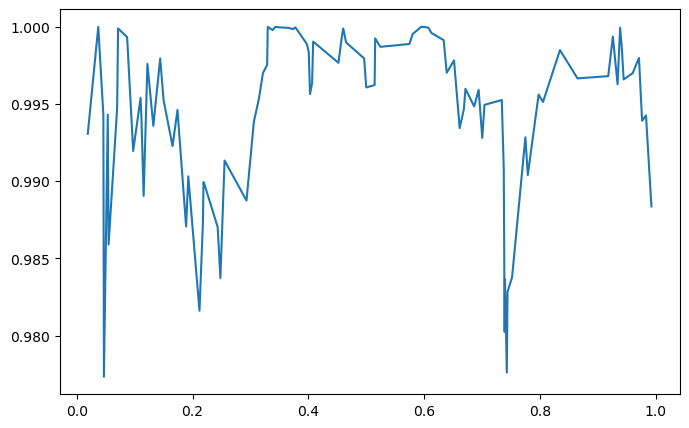

In [1066]:
plt.plot(X[2:-2,0],tot_mse)

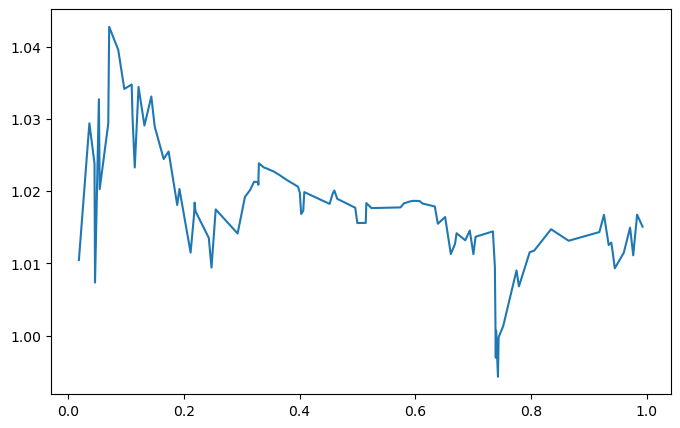

In [1067]:
plt.plot(X[2:-2,0],tot_msep)

In [1068]:
X[np.argmin(tot_mse),0], X[np.argmin(tot_msep),0]

(0.03690607575763072, 0.7388638668361739)

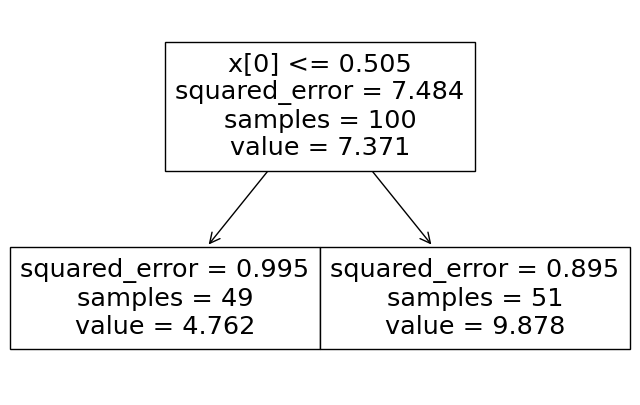

In [1054]:
rt = tree.DecisionTreeRegressor(max_depth=1, min_samples_leaf=2)
rt.fit(X, y)
_= tree.plot_tree(rt)

# Boosting

In [1069]:
def train_ABT(X_train, y_train, J, min_samples_leaf=1, max_iter=100):
    """
    Adaptive Boosting Machine
    ---
    Boost trees, using a parameter J.

    Returns: List of trees 
    
    """
    trees = []
    D = J-1 if J>2 else J

    y_ = y_train
    
    for i in range(max_iter):
        
        rt = tree.DecisionTreeRegressor(max_depth=D, min_samples_leaf=min_samples_leaf, random_state=12)
        path = rt.cost_complexity_pruning_path(X_train, y_)
        ccps, impurities = path.ccp_alphas, path.impurities
        
        rt_store = None
        for c in ccps[::-1]:
            rt_ = tree.DecisionTreeRegressor(max_depth=D, min_samples_leaf=min_samples_leaf, ccp_alpha=c, random_state=12)
            rt_.fit(X_train, y_)
            
            if rt_.tree_.n_leaves <= J:
                rt_store = rt_
            else:
                break

        trees.append(rt_store)
        if rt_store.tree_.n_leaves == 1:
            break

        y_ = y_ - rt_store.predict(X_train)
    return trees 

def boosted_msep(X_train, y_train, alpha, max_depth=1, max_iter=100, min_samples_leaf=10):
    trees = []
    
    y_ = y_train.copy()
    
    for i in range(max_iter):
        # Get the CCPS
        rt = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        rt.fit(X_train, y_)
        path = rt.cost_complexity_pruning_path(X_train, y_)
        ccps, impurities = path.ccp_alphas, path.impurities
    
        for c in ccps[::-1]:
            tr = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, ccp_alpha=c)
            tr.fit(X_train, y_)
            
            pvals, ratios_test = get_pvals_test(tr, X_train, y_)
            ps = np.sum([i for i in pvals if i>=0])
            
            if ps >= alpha:
                break
                
            prev_tree = tr
    
        
        trees.append(prev_tree)
        terminal_nodes = prev_tree.tree_.n_leaves
        if terminal_nodes<2:
            break
        
        y_ = y_ - prev_tree.predict(X_train)

    return trees

def prediction_error(pred, response):
    err = np.mean((pred - response)**2)
    return err
    

def boosted_pred(trees, X):
    """
    Aggregates tree predictions given X
    """
    pred = np.zeros((X.shape[0], len(trees)))
    for i, t in enumerate(trees):
        pred[:, i] = t.predict(X)

    return np.sum(pred, axis=1)

In [1065]:
# Data generation
N = int(1e4) # number of samples
"""
X1 = np.random.normal(-2, 5, (N,1))
X2 = np.random.uniform(10,90, (N,1))
X3 = np.random.poisson(100, (N,1))
X4 = np.random.normal(100, 1, (N,1))
X = np.concatenate([X1, X2, X3,X4], axis=1)
y =  10 + 10*(X1 >10) - 25*np.cos(X2*X3)+ 1/X4
"""
#Neufeld
p = 10 # number of covariates
sig = 5
b = 1
a = -5
X = np.random.normal(0,1, (N,p))
eps = np.random.normal(0,sig, N)

mu = b*(X[:, 0] <= 0)*(1 + a*(X[:,1] >0 ) + ((X[:,1]*X[:,2]) > 0) )
y = mu + eps

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

## Adaptive Boosting

In [956]:
trees = train_ABT(X_train, y_train, J=5)
for t in trees:
    pvals, ratios = get_pvals_test(t, X_train, y_train)
    ps = np.sum([i for i in pvals if i>=0])
    print(ps)
    #print(t.tree_.n_leaves, t.ccp_alpha)

-0.47862138423496847 5.392357672711149
8.668621376273222e-16 5.392357672711149
-1.5347723092418165e-16 5.392357672711149
-1.0231815394945442e-16 5.392357672711149
1.7053025658242405e-16 5.392357672711149
-1.9042545318370686e-16 5.392357672711149
9.444199490293848e-05
0.9999884905764302
0.13232853882354356
0.6459961594518885
1.7629323830350638
0.0


In [216]:
prediction_error(boosted_pred(trees, X_test), y_test)

25.828375488136505

5.08360897322528


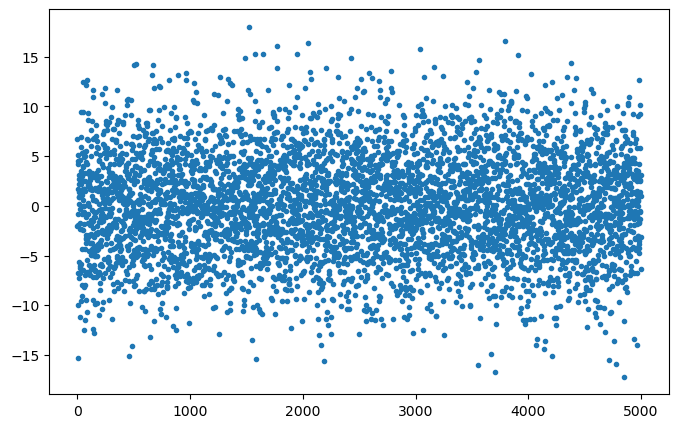

In [125]:
res = boosted_pred(trees, X_test) - y_test
print(res.std())
plt.plot(res, '.')

# Comparisons

In [518]:
# Data generation
N = int(1e4) # number of samples
#Neufeld
p = 10 # number of covariates
sig = 5
b = 1
a = -5
X = np.random.normal(0,1, (N,p))
eps = np.random.normal(0,sig, N)

mu = b*(X[:, 0] <= 0)*(1 + a*(X[:,1] >0 ) + ((X[:,1]*X[:,2]) > 0) )
y = mu + eps

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [520]:
data = []
for j in range(2,10):
    trees = train_ABT(X_train, y_train, J=j)

    msep_train = prediction_error(boosted_pred(trees, X_train), y_train)
    msep_test = prediction_error(boosted_pred(trees, X_test), y_test)

    data.append([j,msep_train,msep_test])
abt_err = pd.DataFrame(data, columns=["J", "msep_train", "msep_test"])
abt_err

,J,msep_train,msep_test
0,2,28.115461,29.244936
1,3,24.327444,26.189040
2,4,24.631596,25.467901
3,5,24.535493,25.449074
4,6,23.526327,26.663134
5,7,24.618843,25.461716
6,8,24.313100,25.806168
7,9,23.754964,26.673842


In [521]:
max_depth = 5
min_samples_leaf = 2

rt = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=1) 
path = rt.cost_complexity_pruning_path(X_train, y_train)
ccps, impurities = path.ccp_alphas, path.impurities

data = []

for c in ccps[:-1]:
    tr = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, ccp_alpha=c, random_state=1)
    tr.fit(X_train, y_train)

    pred = tr.predict(X_train)
    msep = pred - y_train
    msep = msep**2
    msep = np.mean(msep)
    
    pvals, ratios = get_pvals_test(tr, X_train, y_train)
    ps = np.sum([i for i in pvals if i>=0])
    #ps = np.min([i for i in pvals if i>=0])
    ratio = np.max(ratios)
    
    # Test error
    pred = tr.predict(X_test)
    msep_test = pred - y_test
    msep_test = msep_test**2
    msep_test = np.mean(msep_test)

    n_regions = tr.tree_.n_leaves # number of leaves

    pvals_test, ratios_test = get_pvals_test(tr, X_test, y_test)
    pst = np.sum([i for i in pvals_test if i>=0])
    #pst = np.min([i for i in pvals_test if i>=0])
    #ratio_test = np.max(ratios_test)
    
    data.append((c, ps, pst, msep, msep_test, n_regions, ratio, ratio_test))

table = pd.DataFrame(data, columns=["ccps", "p_summed", "p_test_summed", "msep_train", "msep_test", "terminal_regions", "max_ratio", "max_ratio_test"])#.iloc[::-1]
table.iloc[::-1,:]

,ccps,p_summed,p_test_summed,msep_train,msep_test,terminal_regions,max_ratio,max_ratio_test
22,0.273144,0.000000e+00,0.000000e+00,25.093383,25.734875,3,-1.0,-3.0
21,0.067255,3.099127e-10,7.616130e-14,24.820240,25.379046,4,-1.0,-3.0
20,0.066253,2.235559e-01,9.999982e-01,24.685730,25.424504,6,-1.0,-3.0
19,0.063955,2.449741e-01,1.005646e+00,24.619477,25.348265,7,-1.0,-3.0
18,0.055391,2.643907e-01,1.984352e+00,24.555522,25.468528,8,-1.0,-3.0
17,0.052347,5.693638e-01,4.983670e+00,24.389350,25.635825,11,-1.0,-3.0
16,0.049148,6.465994e-01,5.003897e+00,24.337003,25.567321,12,-1.0,-3.0
15,0.046662,7.451508e-01,6.003368e+00,24.287855,25.615420,13,-1.0,-3.0
14,0.046279,8.188009e-01,7.002827e+00,24.241193,25.685680,14,-1.0,-3.0
13,0.043297,8.962663e-01,8.001319e+00,24.194914,25.761477,15,-1.0,-3.0


In [240]:
# Data generation
N = int(1e4) # number of samples
X1 = np.random.normal(-2, 5, (N,1))
X2 = np.random.uniform(10,90, (N,1))
X3 = np.random.poisson(100, (N,1))
X4 = np.random.normal(100, 1, (N,1))
X = np.concatenate([X1, X2, X3,X4], axis=1)
y =  10 + 10*(X1 >10) - 25*(X2*X3)**2 + 1/X4
y = y.reshape(-1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [232]:
data = []
for j in range(2,30):
    trees = train_ABT(X_train, y_train, J=j)

    msep_train = prediction_error(boosted_pred(trees, X_train), y_train)
    msep_test = prediction_error(boosted_pred(trees, X_test), y_test)

    data.append([j,msep_train,msep_test])
abt_err = pd.DataFrame(data, columns=["J", "msep_train", "msep_test"])
abt_err

,J,msep_train,msep_test
0,2,307.778228,308.650014
1,3,306.783160,310.043340
2,4,306.236934,310.220579
3,5,307.153497,309.497782
4,6,306.386130,310.012685
5,7,306.386130,310.012685
6,8,306.386130,310.012685
7,9,306.386130,310.012685
8,10,306.386130,310.012685
9,11,306.386130,310.012685


## Boosting p-Values

In [254]:
def calculate_ratio(rt, X, y):
    prow, pcol = rt.decision_path(X).nonzero()
    data_left_ind = prow[pcol == 1]
    data_right_ind = prow[pcol == 2]

    n_left = np.size(data_left_ind)
    n_right = np.size(data_right_ind)
    n = n_left + n_right

    if np.any(np.array([n_left, n_right, n]) < 2):
        return False, False


    """
    msep_left = (y[data_left_ind] - rt.predict(X[data_left_ind,:]))**2
    msep_left = np.sum(msep_left)/(n_left -1 ) # MSE
    msep_left *= (1 + 1/n_left)*(n_left/n) # Uncertainty correction

    msep_right = (y[data_right_ind] - rt.predict(X[data_right_ind,:]))**2
    msep_right = np.sum(msep_right)/(n_right - 1) # MSE
    msep_right *= ( 1+ 1/n_right)*(n_right/n) # Uncertainty correction

    msep = (y - rt.predict(X))**2
    msep = np.sum(msep)/(n - 1)
    msep *= (1 + 1/n)

    """
    # Everything empirical
    msep_left =  np.var(y[data_left_ind], ddof=1)
    msep_left *= (1 + 1/n_left)*(n_left/n)
    
    msep_right = np.var(y[data_right_ind], ddof=1)
    msep_right *= (1 + 1/n_right)*(n_right/n)
    
    msep = np.var(y, ddof=1)
    msep *= (1 + 1/n)
        
    ratio = msep_left + msep_right
    ratio /= msep
    
    return ratio



In [255]:
trees = boosted_msep(X_train, y_train, 0.0001)

for t in trees:
    print(t.tree_.n_leaves)

NameError: name 'get_pvals_test' is not defined

## ABT vs Boost pVals

In [412]:
def trees_it_error(trees, X,y):
    errors = []
    for i in range(len(trees)):
        error = prediction_error( boosted_pred(trees[:i+1], X), y)
        errors.append([i+1, error])
    return errors

In [413]:
N = int(2e2)
std = 5
X = np.random.uniform(size=(N,1))
y = 10 + 10*(X[:,0] > 0.7) - 25*(X[:,0] < 0.2) + 3*(X[:,0] < 0.5)
#y = y +  np.sin(8*np.pi*X[:,0])

eps = np.random.normal(0, std, size=N)
y = y + eps

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [414]:
J = 3
alpha = 0.05

abt_trees = ABT(X_train, y_train, J)
p_trees = boosted_msep(X_train, y_train, alpha)


train_error_abt = pd.DataFrame(trees_it_error(abt_trees, X_train, y_train))
test_error_abt = pd.DataFrame(trees_it_error(abt_trees, X_test, y_test))
error_abt = train_error_abt.merge(test_error_abt, on=0)
error_abt.columns = ["iteration", "train_error", "test_error"]

train_error_p = pd.DataFrame(trees_it_error(p_trees, X_train, y_train))
test_error_p = pd.DataFrame(trees_it_error(p_trees, X_test, y_test))
error_p = train_error_p.merge(test_error_p, on=0)
error_p.columns = ["iteration", "train_error", "test_error"]

error_p

,iteration,train_error,test_error
0,1,30.826089,24.838225
1,2,30.826089,24.838225


In [415]:
error_abt

,iteration,train_error,test_error
0,1,33.035140,26.224249
1,2,30.818341,25.004359
2,3,29.778199,24.427478
3,4,29.778199,24.427478


In [408]:
plotdf = table.loc[:, ["iteration", "train_error", "test_error"]].melt("iteration", var_name="case", value_name="val")

ax = sb.lineplot(plotdf, x="iteration", y="val", hue="case")

## Get First time summed ps exceed alpha
alpha = 0.05
ptrain_ind, ptest_ind = table["iteration"].loc[(table[["pvals", "pvals_test"]].cumsum() >= alpha).idxmax()]

# Plot line for stopping
ax.axvline(x = ptrain_ind, label="train stop", color="blue", linestyle = "dashed")# Line on x = 2
ax.axvline(x = ptest_ind, label="test stop", color="orange", linestyle = "dashed")# Line on x = 2

# Annotate the minimum train error
test_min = table.loc[table["test_error"].argmin(), "iteration"]
coord = (test_min, table.loc[table["test_error"].argmin(), "test_error"])
_ = ax.annotate(f'Test min', xy=coord, xytext=coord,
            arrowprops=dict(facecolor='black', headwidth=7, headlength=7))

print(f"Stopping it: Train:{ptrain_ind}, Test:{ptest_ind}")

NameError: name 'table' is not defined

In [829]:
trees = []
metrics = []
J = 2
D = J-1 if J<2 else J

y_ = y_train.copy()
n = len(y_)
sig_0 = np.var(y_, ddof=1)
stop = False
for i in range(50):
    rt_ = rt = tree.DecisionTreeRegressor(max_depth=D, min_samples_leaf=10)
    path = rt.cost_complexity_pruning_path(X_train, y_)
    ccps, impurities = path.ccp_alphas, path.impurities

    rt_store = None
    for c in ccps[::-1]:
        rt_ = rt = tree.DecisionTreeRegressor(max_depth=D, min_samples_leaf=10, ccp_alpha=c)
        rt_.fit(X_train, y_)
        
        if N_terminal(rt_) > J:
            break
        else:
            rt_store = rt_

    trees.append(rt_store)
    
    train_error = prediction_error( boosted_pred(trees, X_train), y_train)
    test_error = prediction_error( boosted_pred(trees, X_test), y_test)

    metrics.append((i+1, train_error, test_error, stop))
    if N_terminal(rt_store) == 1:
        stop = True
        #break
        
    y_ = y_ - rt_store.predict(X_train)

In [830]:
abt_table = pd.DataFrame(metrics, columns=["iteration", "train_error", "test_error", "stop"])
abt_stop = abt_table.loc[abt_table["stop"].idxmax() - 1, "iteration"]

Stopping it: 4


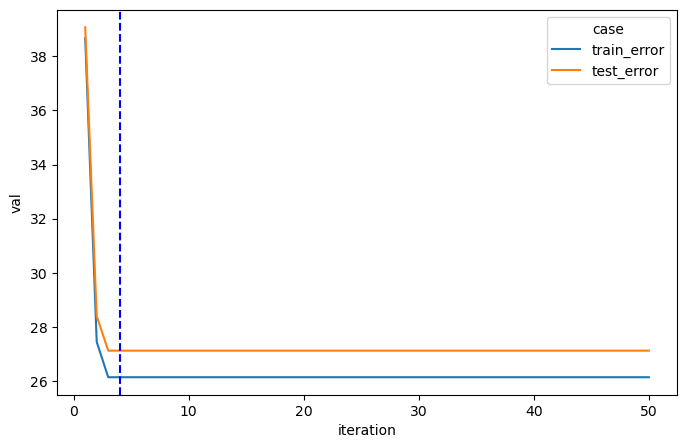

In [831]:
plotabtdf = abt_table.loc[:, ["iteration", "train_error", "test_error"]].melt("iteration", var_name="case", value_name="val")
ax = sb.lineplot(plotabtdf, x="iteration", y="val", hue="case")
ax.axvline(x = abt_stop, label="abt stop", color="blue", linestyle = "dashed")
print(f"Stopping it: {abt_stop}")

In [832]:
full_table = table.merge(abt_table, on="iteration", suffixes=("_our", f"_abt_{J}"))

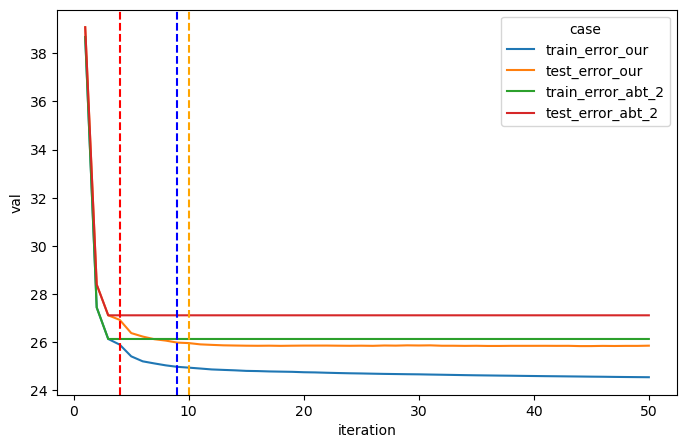

In [833]:
pltfull = full_table[["iteration", "train_error_our", "test_error_our", f"train_error_abt_{J}", f"test_error_abt_{J}"]].melt("iteration", var_name="case", value_name="val")
ax = sb.lineplot(pltfull, x="iteration", y="val", hue="case")

ax.axvline(x = abt_stop, label="abt stop", color="red", linestyle = "dashed")
ax.axvline(x = ptrain_ind, label="train stop", color="blue", linestyle = "dashed")# Line on x = 2
ax.axvline(x = ptest_ind, label="test stop", color="orange", linestyle = "dashed")# Line on x = 2

In [786]:
data = []
for i in range(int(1e4)):
    N = int(1e3)
    std = 5
    X = np.random.uniform(size=(N,1))

    eps = np.random.normal(0, std, size=N)
    y = eps

    rt = tree.DecisionTreeRegressor(max_depth=1, min_samples_leaf=2)
    rt.fit(X, y)
    
    diff = prediction_error(rt.predict(X), y) - np.var(y,ddof=1)

    x = rt.tree_.impurity[0] - np.max(rt.tree_.impurity[1:])
    #print(rt.tree_.impurity)
    data.append(x)

<Axes: ylabel='Count'>

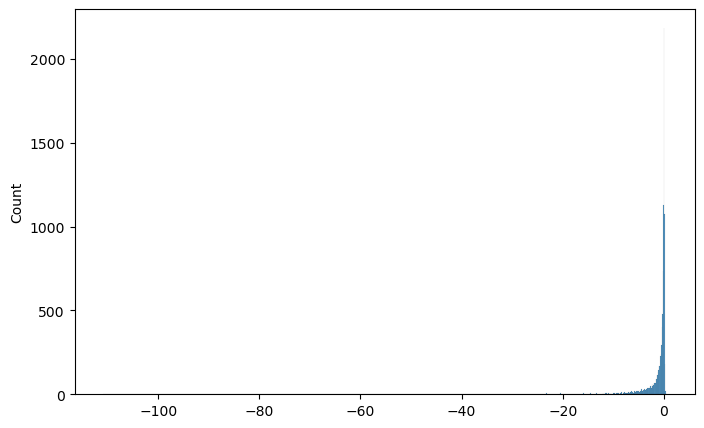

In [787]:
sb.histplot(data)

# Testing ABT effective alphas

In [1166]:
N = int(1e1)
X = np.random.normal(0,1,(N,1))
y = np.random.normal(0,1,N)

alphas = []
Q = np.eye(N) - (1/N)*np.ones((N,N))

In [1167]:
for i in range(int(1e2)):
    tr = tree.DecisionTreeRegressor(max_depth=1,random_state=1)
    tr.fit(X,y)
    
    imp = tr.tree_.impurity
    n_left, n_right = tr.tree_.n_node_samples[1], tr.tree_.n_node_samples[2]
    alphas.append(imp[0])
    #alphas.append(imp[0]-(n_left/N)*imp[1] - (n_right/N)*imp[2])
    
    """
    path = tr.decision_path(X).toarray()
    left_ind = path[:,1]
    right_ind = path[:,2]
    y_left = y[np.bool_(left_ind)]
    y_right = y[np.bool_(right_ind)]
    n_left = len(y_left)
    n_right = len(y_right)
    
    sse = N*np.var(y)
    sse_l = n_left*np.var(y_left)
    sse_r = n_right*np.var(y_right)

    alpha_eff = (sse-sse_l-sse_r)/N
    alphas.append(alpha_eff)
    """
    """
    ccp_path = tr.cost_complexity_pruning_path(X,y)
    ccp = ccp_path["ccp_alphas"]
    alphas.append(ccp[-1])
    """
    y=y-tr.predict(X)

In [1192]:
N = int(1e2)
X = np.random.normal(0,1,(N,1))
y = np.random.normal(0,1,N)

alphas = []
Q = np.eye(N)#- (1/N)*np.ones((N,N))
l = []
for i in range(10000):
    #tr = tree.DecisionTreeRegressor(max_depth=1,random_state=1)
    tr.fit(X,y)
   
    dp_ = tr.decision_path(X).toarray()
    left_ = np.bool_(dp_[:,1])
    right_ = np.bool_(dp_[:,2])
    
    v_l = np.zeros(N)
    v_r = np.zeros(N)
    v_l[left_] = 1/left_.sum()
    v_r[right_] = 1/right_.sum()
    
    T = np.zeros((N,N))
    T[left_, :] = v_l
    T[right_, :] = v_r
    
    B = (np.eye(N) - T)
    Q = ((B.T).dot(Q)).dot(B)
    y=y-tr.predict(X)

    #u,V = np.linalg.eigh(Q)
    #print(u)
    
    l.append(np.sum(np.diag(Q)))
    

5.3508873973873845

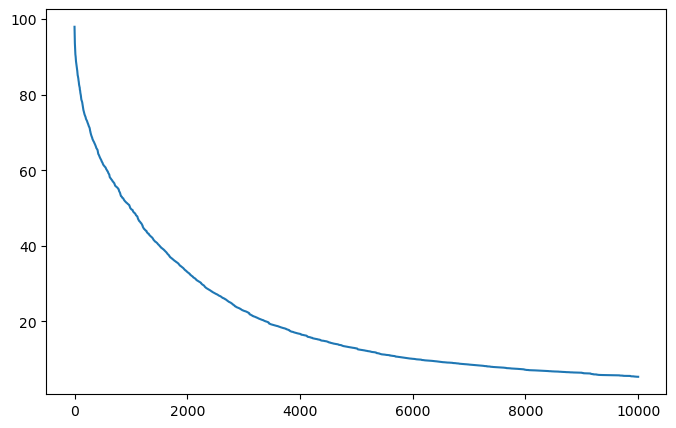

In [1193]:
plt.plot(l)
l[-1]

In [1152]:
u, V = np.linalg.eigh(np.eye(len(v_l)) - T)
u

array([0.00000000e+00, 6.10622664e-16, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00])

In [1186]:
u,V = np.linalg.eigh(np.eye(len(v_l)) - T)

np.sum(u)

98.0

In [1179]:
T

array([[0.0212766 , 0.        , 0.        , ..., 0.        , 0.0212766 ,
        0.0212766 ],
       [0.        , 0.01886792, 0.01886792, ..., 0.01886792, 0.        ,
        0.        ],
       [0.        , 0.01886792, 0.01886792, ..., 0.01886792, 0.        ,
        0.        ],
       ...,
       [0.        , 0.01886792, 0.01886792, ..., 0.01886792, 0.        ,
        0.        ],
       [0.0212766 , 0.        , 0.        , ..., 0.        , 0.0212766 ,
        0.0212766 ],
       [0.0212766 , 0.        , 0.        , ..., 0.        , 0.0212766 ,
        0.0212766 ]])

In [1180]:
T - T.T.dot(T)

array([[1.04083409e-17, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.04083409e-17, 1.04083409e-17],
       [0.00000000e+00, 1.73472348e-17, 1.73472348e-17, ...,
        1.73472348e-17, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.73472348e-17, 1.73472348e-17, ...,
        1.73472348e-17, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 1.73472348e-17, 1.73472348e-17, ...,
        1.73472348e-17, 0.00000000e+00, 0.00000000e+00],
       [1.04083409e-17, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.04083409e-17, 1.04083409e-17],
       [1.04083409e-17, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.04083409e-17, 1.04083409e-17]])

# Bonferonni Corrections to covariate p-values

In [2]:
# Data generation
N = int(400) # number of samples

p = 10 # number of covariates
sig = 5
b = 5
a = 0.5
X = np.random.normal(0,1, (N,p))
eps = np.random.normal(0,sig, N)

mu = b*(X[:, 0] <= 0)*(1 + a*(X[:,1] >0 ) + ((X[:,1]*X[:,2]) > 0) )
y = mu + eps

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [3]:
tr = tree.DecisionTreeRegressor(max_depth=1, random_state=1)
tr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1, random_state=1)

In [296]:
def P_T(t,n):
    a_n = 1 / (np.sqrt(2*np.log(np.log(n))))
    K_t = t - a_n*(np.log(np.log(np.log(n))) + np.log(2)) / ( np.sqrt(2*np.log(np.log(n))))
    p = (norm.cdf(K_t))**(2*np.log(n/2))
    return p

def P_U(u,n):
	K = np.sqrt(u) - ((2*(np.log(np.log(n))))**(-1/2))*(np.log(np.log(np.log(n))) + np.log(2))
	p = d*(1 - norm.cdf(K)**(2*np.log(n/2)))
	return p

def get_ps(tr, metric=False):
    n_nodes = tr.tree_.node_count
    children_left = tr.tree_.children_left
    children_right = tr.tree_.children_right
    feature = tr.tree_.feature
    threshold = tr.tree_.threshold
    values = tr.tree_.value

    n_samples = tr.tree_.n_node_samples
    impurities = tr.tree_.impurity

    ps = -np.ones(len(values))

    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaves = np.zeros(shape=n_nodes, dtype=bool)
    stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
    while len(stack) > 0:
        # `pop` ensures each node is only visited once
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
        # If the left and right child of a node is not the same we have a split
        # node
        is_split_node = children_left[node_id] != children_right[node_id]
        # If a split node, append left and right children and depth to `stack`
        # so we can loop through them
        if is_split_node:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))

            # Calculate p-vals for this node
            #Impurty = SSE/N
            E = n_samples[node_id]*impurities[node_id] \
                    - (n_samples[children_left[node_id]]*impurities[children_left[node_id]] \
                    + n_samples[children_right[node_id]]*impurities[children_right[node_id]])
            E = np.sqrt(E/impurities[node_id])
            ps[node_id] = 1 - P_T(E, n_samples[node_id])
        else:
            is_leaves[node_id] = True
    return ps

def prune(tr,nodes_to_prune):
    """
    mutates the original tree!
    """
    for n in nodes_to_prune:
        tr.tree_.children_left[n] = -1

In [214]:
tr = tree.DecisionTreeRegressor(max_depth=5, random_state=1)
tr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=1)

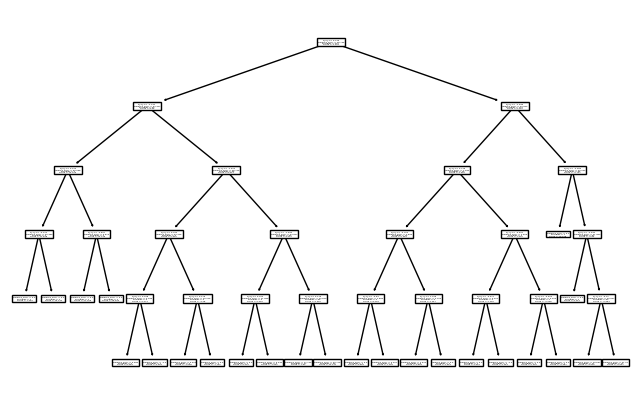

In [215]:
_ = tree.plot_tree(tr)

In [216]:
significance = 0.05
d = X.shape[1]
alpha = significance/d
print(get_ps(tr), "\n", get_ps(tr) >=alpha, "\n")

nts = [index for index, value in enumerate(get_ps(tr) >=alpha) if value]
nts

[ 0.          0.00620826  0.0091385   0.         -1.         -1.
  0.         -1.         -1.          0.00550247  0.05082457  0.
 -1.         -1.          0.         -1.         -1.          0.03377349
  0.         -1.         -1.          0.01901887 -1.         -1.
  0.00259697  0.04353663  0.0604892   0.         -1.         -1.
  0.12177078 -1.         -1.          0.00621752  0.         -1.
 -1.          0.         -1.         -1.          0.19602072 -1.
  0.22329194 -1.          0.28553662 -1.         -1.        ] 
 [False  True  True False False False False False False  True  True False
 False False False False False  True False False False  True False False
 False  True  True False False False  True False False  True False False
 False False False False  True False  True False  True False False] 



/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:2: RuntimeWarning: invalid value encountered in sqrt
  a_n = 1 / (np.sqrt(2*np.log(np.log(n))))
/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:3: RuntimeWarning: invalid value encountered in log
  K_t = t - a_n*(np.log(np.log(np.log(n))) + np.log(2)) / ( np.sqrt(2*np.log(np.log(n))))
/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:3: RuntimeWarning: invalid value encountered in sqrt
  K_t = t - a_n*(np.log(np.log(np.log(n))) + np.log(2)) / ( np.sqrt(2*np.log(np.log(n))))


[1, 2, 9, 10, 17, 21, 25, 26, 30, 33, 40, 42, 44]

In [217]:
prune(tr, nts)

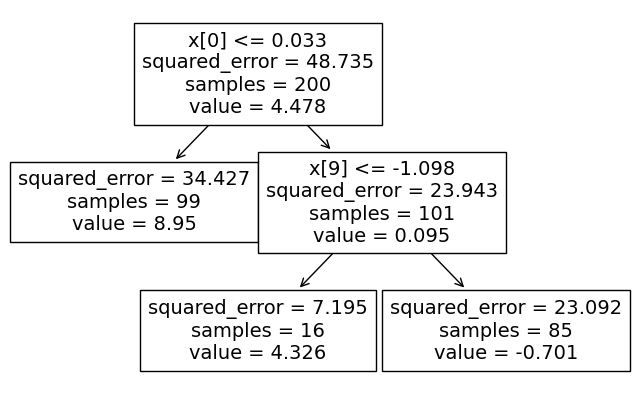

In [218]:
_ = tree.plot_tree(tr)

# Neufeldt Data

In [316]:
def sample_neufeld(N,p,a,b, sig=5):
    # Data generation
    sig = 5
    X = np.random.normal(0,1, (N,p))
    eps = np.random.normal(0,sig, N)
    
    mu = b*(X[:, 0] <= 0)*(1 + a*(X[:,1] >0 ) + ((X[:,1]*X[:,2]) > 0) )
    y = mu + eps
    
    return X, y

/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:2: RuntimeWarning: invalid value encountered in sqrt
  a_n = 1 / (np.sqrt(2*np.log(np.log(n))))
/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:3: RuntimeWarning: invalid value encountered in log
  K_t = t - a_n*(np.log(np.log(np.log(n))) + np.log(2)) / ( np.sqrt(2*np.log(np.log(n))))
/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:3: RuntimeWarning: invalid value encountered in sqrt
  K_t = t - a_n*(np.log(np.log(np.log(n))) + np.log(2)) / ( np.sqrt(2*np.log(np.log(n))))
/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:2: RuntimeWarning: invalid value encountered in sqrt
  a_n = 1 / (np.sqrt(2*np.log(np.log(n))))
/var/folders/wb/2dhht1p95s56g8h4dpvd9kh5jc9p23/T/ipykernel_25770/3190807571.py:3: RuntimeWarning: invalid value encountered in log
  K_t = t - a_n*(np.log(np.log(np.log(n))) + np.log(2)) / ( np.sqrt(2*np.log

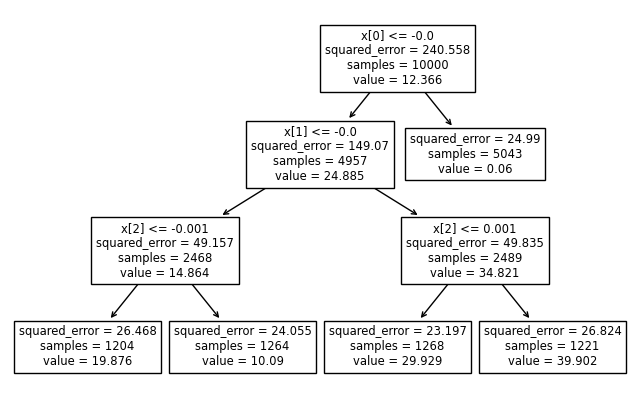

In [357]:
import itertools
N = 10000
d = 10
a_ = [2]
b_ = [10]

significance = 0.05
d = X.shape[1]
alpha = significance/d

cartesian_product = itertools.product(a_, b_)

# Train model
## Build
X_train, y_train = sample_neufeld(N,d,a,b)
X_test, y_test = sample_neufeld(N ,d,a,b)
tr = tree.DecisionTreeRegressor(max_depth=5, random_state=1)
tr.fit(X_train, y_train)

train_err = []
test_err = []
ps = [1e-4, 1e-3, 1e-2, 5e-2, 0.1, 0.5, 1,10,100]
for a,b in cartesian_product:
    for alpha_ in ps[::-1]:
        nts = [index for index, value in enumerate(get_ps(tr) >= alpha_/d) if value]
        prune(tr, nts)
        
        ## Evaluate
        pred = tr.predict(X_train)
        err = np.mean((pred - y_train)**2)
        train_err.append(err)
        
        pred = tr.predict(X_test)
        err = np.mean((pred - y_test)**2)
        test_err.append(err)

        tree.plot_tree(tr)
    break

In [358]:
train_err, test_err

([24.599939709710174,
  24.599939709710174,
  24.720641291569656,
  24.842311214833277,
  24.946975053218182,
  25.012195619114863,
  25.046079376227404,
  25.046079376227404,
  25.046079376227404],
 [25.15211314447195,
  25.15211314447195,
  25.01795671665364,
  24.8884122385262,
  24.818296729240185,
  24.79987126949459,
  24.79308288125827,
  24.79308288125827,
  24.79308288125827])

In [359]:
np.argmin(test_err)

6

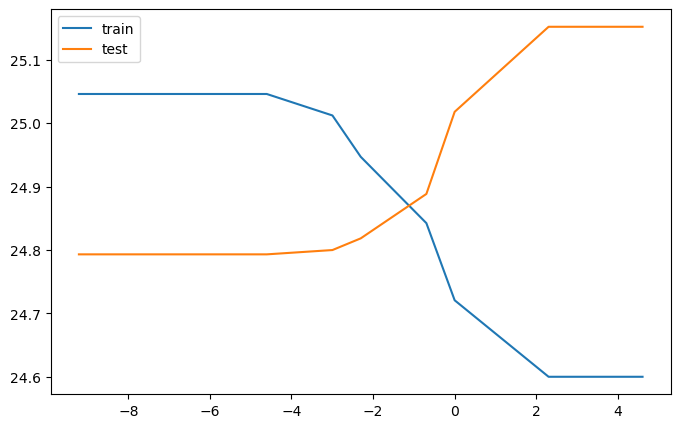

In [360]:
plt.plot(np.log(ps[::-1]), train_err)
plt.plot(np.log(ps[::-1]), test_err)
plt.legend(["train", "test"])

In [348]:
i = np.argmin(test_err)
ps[i]

0.1